# Optimización del Umbral de Similitud en un Sistema RAG

Este experimento evalúa cómo varía el rendimiento de un sistema RAG al ajustar el umbral de similitud (basado en la distancia L2) al recuperar documentos.

Para cada umbral, se seleccionan los documentos con puntaje L2 menor o igual que ese valor, y se comparan con etiquetas de relevancia generadas por un modelo LLM.

Se evalúa el desempeño mediante métricas estándar de recuperación, enfocadas en los 10 documentos más similares por consulta.


## Supuestos y Métricas de Evaluación

- Se usan los top-10 documentos más similares por query (evaluación truncada).
- Cada documento fue etiquetado como relevante o no relevante mediante un modelo LLM.
- Se asume que no existen documentos relevantes fuera del top-10.

Las métricas utilizadas para cada umbral son:

- Precision@10: proporción de documentos relevantes entre los seleccionados.
- Recall@10: proporción de documentos relevantes recuperados respecto al total de relevantes.
- F1@10: promedio armónico entre Precision@10 y Recall@10.

El objetivo es encontrar el umbral que maximiza el F1@10, logrando un equilibrio entre precisión y cobertura.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open("./results.json", encoding="utf-8") as f:
    results = json.load(f)

print(f"Se cargaron {len(results)} queries.")


Se cargaron 30 queries.


La siguiente gráfica muestra la distribución de los puntajes de similitud L2 entre las consultas (queries) y los documentos recuperados en el sistema RAG. Esta métrica L2 mide la distancia entre embeddings normalizados, donde valores menores indican mayor similitud semántica.

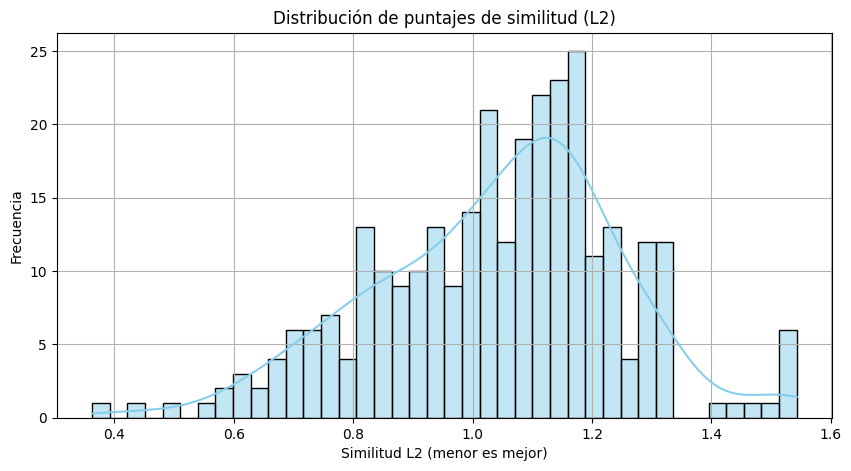

In [2]:
all_scores = []
for entry in results:
    for chunk in entry["chunk_scores"]:
        all_scores.append(chunk["score"])

plt.figure(figsize=(10, 5))
sns.histplot(all_scores, bins=40, kde=True, color='skyblue')
plt.title("Distribución de puntajes de similitud (L2)")
plt.xlabel("Similitud L2 (menor es mejor)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()


Los puntajes de similitud obtenidos oscilan entre 0.36 y 1.54, con un promedio alrededor de 1.04 y una mediana de 1.08. La mayoría de los valores se concentra en el rango intercuartil, entre aproximadamente 0.92 y 1.17, lo que indica que la mayoría de los documentos recuperados están moderadamente cerca semánticamente a las queries.

Esta distribución sugiere que el sistema recupera principalmente documentos con similitud L2 en ese rango medio, aunque existen algunos casos con similitud muy alta (menores a 0.5) y otros más alejados (hasta 1.54). La cola derecha más ligera indica la presencia ocasional de documentos menos relacionados semánticamente.

Este comportamiento respalda la elección de evaluar umbrales de similitud dentro del rango aproximadamente entre 0.7 y 1.4 para filtrar resultados, ya que pequeños ajustes en esta zona pueden influir significativamente en la calidad y cantidad de documentos recuperados.

La siguiente gráfica representa la cantidad promedio de documentos recuperados por query en función del umbral de similitud L2. Este umbral define qué tan estricta es la selección de documentos: un valor bajo selecciona solo documentos muy cercanos a la consulta, mientras que un valor alto permite incluir documentos menos similares.

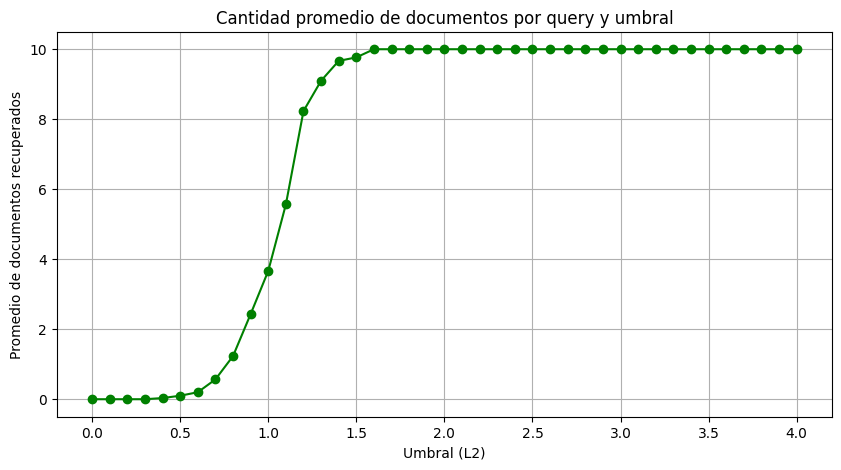

In [3]:
thresholds = np.round(np.arange(0.0, 4.01, 0.1), 2).tolist()

avg_chunks = []

for t in thresholds:
    total = sum(
        sum(chunk["score"] <= t for chunk in entry["chunk_scores"])
        for entry in results
    )
    avg = total / len(results)
    avg_chunks.append(avg)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, avg_chunks, marker="o", color="green")
plt.title("Cantidad promedio de documentos por query y umbral")
plt.xlabel("Umbral (L2)")
plt.ylabel("Promedio de documentos recuperados")
plt.grid(True)
plt.show()


Como se observa, para umbrales menores a 0.6, el sistema recupera casi ningún documento, reflejando un filtrado muy estricto. A partir de 0.7, la cantidad de documentos recuperados comienza a crecer de forma acelerada, alcanzando el límite máximo de 10 documentos por query alrededor del umbral 1.6. Esto confirma que el rango entre 1.0 y 1.5 es crítico para balancear la cobertura sin saturar con documentos poco relevantes.

La gráfica a continuación muestra cómo varían las métricas F1, precisión y recall al ajustar el umbral de similitud (L2) para filtrar los documentos recuperados. El objetivo es identificar el umbral que maximiza la capacidad del sistema para recuperar documentos relevantes sin incluir demasiados irrelevantes.

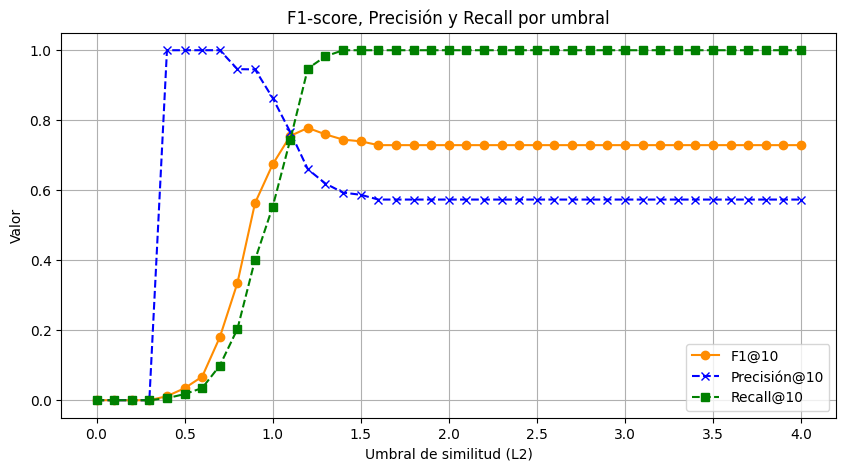

In [4]:
f1_data = []

total_relevant_by_query = {
    entry["query"]: sum(chunk["is_relevant"] for chunk in entry["chunk_scores"])
    for entry in results
}

for t in thresholds:
    TP = FP = FN = 0

    for entry in results:
        query = entry["query"]
        chunks = entry["chunk_scores"]
        
        retrieved = [c for c in chunks if c["score"] <= t]
        not_retrieved = [c for c in chunks if c["score"] > t]

        TP += sum(c["is_relevant"] for c in retrieved)
        FP += sum(not c["is_relevant"] for c in retrieved)
        FN += sum(c["is_relevant"] for c in not_retrieved)

    precision_val = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision_val * recall / (precision_val + recall) if (precision_val + recall) > 0 else 0

    f1_data.append({
        "threshold": t,
        "precision": precision_val,
        "recall": recall,
        "f1_score": f1
    })

f1_df = pd.DataFrame(f1_data)

plt.figure(figsize=(10, 5))
plt.plot(f1_df["threshold"], f1_df["f1_score"], marker="o", color="darkorange", label="F1@10")
plt.plot(f1_df["threshold"], f1_df["precision"], marker="x", color="blue", linestyle="--", label="Precisión@10")
plt.plot(f1_df["threshold"], f1_df["recall"], marker="s", color="green", linestyle="--", label="Recall@10")

plt.title("F1-score, Precisión y Recall por umbral")
plt.xlabel("Umbral de similitud (L2)")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
best_row = f1_df.loc[f1_df["f1_score"].idxmax()]
print(f"✅ Mejor umbral según F1@10: {best_row['threshold']}")
print(f"   F1@10: {best_row['f1_score']:.3f}")
print(f"   Precisión@10: {best_row['precision']:.3f}")
print(f"   Recall@10: {best_row['recall']:.3f}")


✅ Mejor umbral según F1@10: 1.2
   F1@10: 0.778
   Precisión@10: 0.660
   Recall@10: 0.948


### Análisis de resultados

El mejor umbral para maximizar el F1@10 es 1.20, donde se alcanza un F1 de aproximadamente 0.778. En este punto, la precisión es cercana a 0.66, lo que indica que cerca de dos tercios de los documentos recuperados son relevantes. El recall es alto, alrededor de 0.95, lo que muestra que el sistema recupera la gran mayoría de documentos relevantes disponibles. Esto refleja un buen balance entre recuperar suficientes documentos relevantes (alto recall) y mantener la calidad de los documentos (precisión moderada-alta). Umbrales ligeramente superiores (1.3, 1.4, 1.5) mantienen recall casi perfecto pero la precisión disminuye, afectando el F1. Por debajo de 1.1 la precisión puede ser mayor, pero a costa de un recall más bajo, disminuyendo el F1.

En resumen, un umbral en torno a 1.2 es la mejor opción para nuestro sistema.
